In [ ]:
## DEEP Q LEARNING

Checkpoint saved at episode 0
Episode 0: Reward=-5089517.00, Served=82, AvgWait=50.51
Episode 100: Reward=-4489301.00, Served=103, AvgWait=48.08
Episode 200: Reward=-11159010.00, Served=48, AvgWait=76.10
Episode 300: Reward=-13122826.00, Served=37, AvgWait=81.97
Episode 400: Reward=-12186599.00, Served=42, AvgWait=82.97
Episode 500: Reward=-12599468.00, Served=27, AvgWait=80.25
Episode 600: Reward=-11283546.00, Served=64, AvgWait=81.90
Episode 700: Reward=-9704846.00, Served=68, AvgWait=75.34
Episode 800: Reward=-10277902.00, Served=65, AvgWait=78.46
Episode 900: Reward=-12349349.00, Served=32, AvgWait=74.67
Checkpoint saved at episode 1000
Episode 1000: Reward=-12962319.00, Served=34, AvgWait=83.19
Episode 1100: Reward=-8290431.00, Served=66, AvgWait=66.54
Episode 1200: Reward=-11161989.00, Served=15, AvgWait=77.82
Episode 1300: Reward=-10151931.00, Served=50, AvgWait=82.38
Episode 1400: Reward=-12229791.00, Served=23, AvgWait=82.79
Episode 1500: Reward=-11068714.00, Served=66, AvgWai

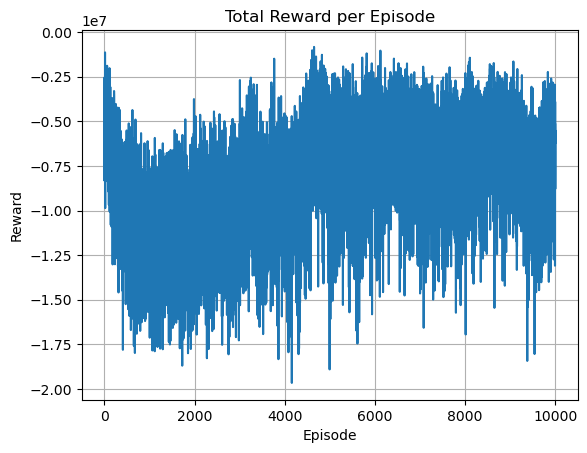

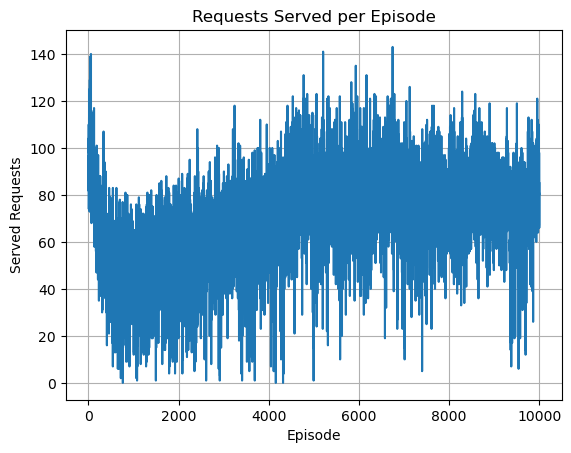

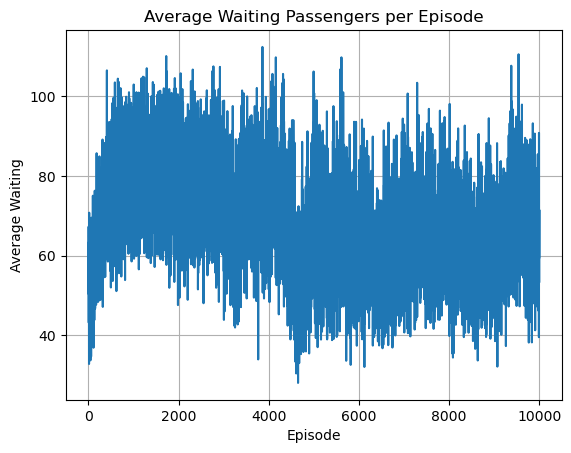


Overall Average Waiting Time across 10000 episodes: 67.79 passengers per timestep


In [1]:
import numpy as np
import random, os
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd

#  ENVIRONMENT CONSTANTS 
NUM_ELEVATORS = 3  # Number of elevator
NUM_FLOORS = 10  # Number of Floors
MAX_CAPACITY = 20  # Max passengers per elevator
EPISODES = 10000  # Number of Trainging episodes
MAX_STEPS = 100  # Number of steps per episode
ARRIVAL_RATE = [0.2] * NUM_FLOORS  # Arrival rate

# SAVING CHECKPOINTS
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# PASSENGER CLASS 
class Passenger:
    def __init__(self, start, dest, arrival_time):
        self.start = start
        self.dest = dest
        self.arrival_time = arrival_time

# ENVIRONMENT CLASS
class ElevatorEnvLarge:
    def __init__(self):
        self.reset()
# Reset the episode to an empty building at t=0.
# Returns the state vector.
    def reset(self):
        self.elevator_positions = [0] * NUM_ELEVATORS
        self.elevator_directions = [0] * NUM_ELEVATORS
        self.elevator_loads = [[] for _ in range(NUM_ELEVATORS)]
        self.car_calls = [[0] * NUM_FLOORS for _ in range(NUM_ELEVATORS)]  # new car calls
        self.hall_requests = {floor: {'up': [], 'down': []} for floor in range(NUM_FLOORS)}
        self.time_step = 0
        return self._get_state()

    def poisson_arrivals(self): # arrival rate according to poisson Process
        for floor in range(NUM_FLOORS):
            n_arrivals = np.random.poisson(ARRIVAL_RATE[floor])
            for _ in range(n_arrivals):
                dest = np.random.choice([f for f in range(NUM_FLOORS) if f != floor])
                direction = 'up' if dest > floor else 'down'
                self.hall_requests[floor][direction].append(Passenger(floor, dest, self.time_step))

    def _get_state(self):
        state = []
        # Elevator positions, directions, loads
        state.extend(self.elevator_positions)
        state.extend(self.elevator_directions)
        state.extend([len(load) for load in self.elevator_loads])
        # Car calls
        for car in self.car_calls:
            state.extend(car)
        # Hall calls
        for floor in range(NUM_FLOORS):
            state.append(1 if len(self.hall_requests[floor]['up']) > 0 else 0)
            state.append(1 if len(self.hall_requests[floor]['down']) > 0 else 0)
        return np.array(state, dtype=np.float32)

    def step(self, actions):
        served = 0
        total_waiting = sum(len(self.hall_requests[f]['up']) + len(self.hall_requests[f]['down']) for f in range(NUM_FLOORS))
        wait_squared = sum([(self.time_step - p.arrival_time) ** 2 for f in self.hall_requests for d in ['up', 'down'] for p in self.hall_requests[f][d]])
        for i in range(NUM_ELEVATORS):
            pos = self.elevator_positions[i]
            action = actions[i]
            if action == 1 and pos < NUM_FLOORS - 1:
                self.elevator_positions[i] += 1
                self.elevator_directions[i] = 1
            elif action == 2 and pos > 0:
                self.elevator_positions[i] -= 1
                self.elevator_directions[i] = 2
            elif action == 3:
                # Drop off
                self.elevator_loads[i] = [p for p in self.elevator_loads[i] if p.dest != pos]
                self.car_calls[i][pos] = 0
                # Pick up
                for direction in ['up', 'down']:
                    while self.hall_requests[pos][direction] and len(self.elevator_loads[i]) < MAX_CAPACITY:
                        p = self.hall_requests[pos][direction].pop(0)
                        self.elevator_loads[i].append(p)
                        self.car_calls[i][p.dest] = 1
                        served += 1
                self.elevator_directions[i] = 0

        self.poisson_arrivals()
        self.time_step += 1
        reward = -wait_squared
        done = self.time_step >= MAX_STEPS
        return self._get_state(), reward, done, {'served': served, 'waiting': total_waiting}

# DQN AGENT 
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x):
        return self.layers(x)

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.model = DQN(state_size, action_size)
        self.target = DQN(state_size, action_size)
        self.memory = deque(maxlen=5000)
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.loss_fn = nn.MSELoss()
        self.epsilon = 1.0
        self.min_epsilon = 0.1
        self.epsilon_decay = 0.995
        self.gamma = 0.95
        self.state_size = state_size
        self.action_size = action_size

    def update_target(self):
        self.target.load_state_dict(self.model.state_dict())

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.model(state_tensor)).item()

    def remember(self, s, a, r, s2, done):
        self.memory.append((s, a, r, s2, done))

    def learn(self, batch_size):
        if len(self.memory) < batch_size: return
        batch = random.sample(self.memory, batch_size)
        s, a, r, s2, done = zip(*batch)
        s = torch.FloatTensor(np.array(s))
        a = torch.LongTensor(a).unsqueeze(1)
        r = torch.FloatTensor(np.array(r))
        s2 = torch.FloatTensor(np.array(s2))
        done = torch.FloatTensor(np.array(done))
        q_target = r + self.gamma * self.target(s2).max(1)[0] * (1 - done)
        q_value = self.model(s).gather(1, a).squeeze()
        loss = self.loss_fn(q_value, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# TRAINING
env = ElevatorEnvLarge()
STATE_SIZE = len(env._get_state())
ACTION_SIZE = 4 ** NUM_ELEVATORS
agent = DQNAgent(STATE_SIZE, ACTION_SIZE)

rewards, waiting, served = [], [], []
TARGET_UPDATE = 50
BATCH_SIZE = 64

for episode in range(EPISODES):
    state = env.reset()
    ep_reward, ep_served, ep_wait = 0, 0, 0

    for _ in range(MAX_STEPS):
        action_idx = agent.act(state)
        actions = []
        tmp = action_idx
        for _ in range(NUM_ELEVATORS):
            actions.append(tmp % 4)
            tmp //= 4
        actions = actions[::-1]
        next_state, reward, done, info = env.step(actions)
        agent.remember(state, action_idx, reward, next_state, done)
        agent.learn(BATCH_SIZE)
        state = next_state
        ep_reward += reward
        ep_served += info['served']
        ep_wait += info['waiting']
        if done: break

    if episode % TARGET_UPDATE == 0:
        agent.update_target()
    if agent.epsilon > agent.min_epsilon:
        agent.epsilon *= agent.epsilon_decay

    rewards.append(ep_reward)
    served.append(ep_served)
    waiting.append(ep_wait / MAX_STEPS)

    # Save checkpoint every 1000 episodes
    if episode % 1000 == 0:
        torch.save(agent.model.state_dict(), os.path.join(CHECKPOINT_DIR, f"model_ep_{episode}.pth"))
        print(f"Checkpoint saved at episode {episode}")

    if episode % 100 == 0:
        print(f"Episode {episode}: Reward={ep_reward:.2f}, Served={ep_served}, AvgWait={ep_wait/MAX_STEPS:.2f}")

#SAVING RESULTS 
df = pd.DataFrame({
    'Episode': list(range(EPISODES)),
    'Total Reward': rewards,
    'Requests Served': served,
    'Average Waiting': waiting
})
df.to_csv(os.path.join(CHECKPOINT_DIR, "training_metrics.csv"), index=False)

# PLOTS 
plt.figure()
plt.plot(rewards)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(served)
plt.title("Requests Served per Episode")
plt.xlabel("Episode")
plt.ylabel("Served Requests")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(waiting)
plt.title("Average Waiting Passengers per Episode")
plt.xlabel("Episode")
plt.ylabel("Average Waiting")
plt.grid(True)
plt.show()


overall_avg_waiting = np.mean(waiting)
print(f"\nOverall Average Waiting Time across {EPISODES} episodes: {overall_avg_waiting:.2f} passengers per timestep")

In [2]:
## BASLINE TRADITIONAL Q LEARNING TABULAR Q LEARNING

Q-table checkpoint saved at episode 0 -> checkpoints\q_table_ep_0.pkl
[Q-Learn] Episode 0: Reward=-5098492.00, Served=140, AvgWait=51.99, Eps=0.998
[Q-Learn] Episode 100: Reward=-4830279.00, Served=160, AvgWait=48.06, Eps=0.817
[Q-Learn] Episode 200: Reward=-6677555.00, Served=104, AvgWait=53.37, Eps=0.669
[Q-Learn] Episode 300: Reward=-6491521.00, Served=96, AvgWait=61.16, Eps=0.547
[Q-Learn] Episode 400: Reward=-8154753.00, Served=90, AvgWait=62.95, Eps=0.448
[Q-Learn] Episode 500: Reward=-8388788.00, Served=92, AvgWait=64.21, Eps=0.367
[Q-Learn] Episode 600: Reward=-5313112.00, Served=94, AvgWait=56.31, Eps=0.300
[Q-Learn] Episode 700: Reward=-12441235.00, Served=55, AvgWait=83.15, Eps=0.246
[Q-Learn] Episode 800: Reward=-9890815.00, Served=72, AvgWait=68.98, Eps=0.201
[Q-Learn] Episode 900: Reward=-10685921.00, Served=66, AvgWait=78.18, Eps=0.165
Q-table checkpoint saved at episode 1000 -> checkpoints\q_table_ep_1000.pkl
[Q-Learn] Episode 1000: Reward=-11164743.00, Served=66, AvgWa

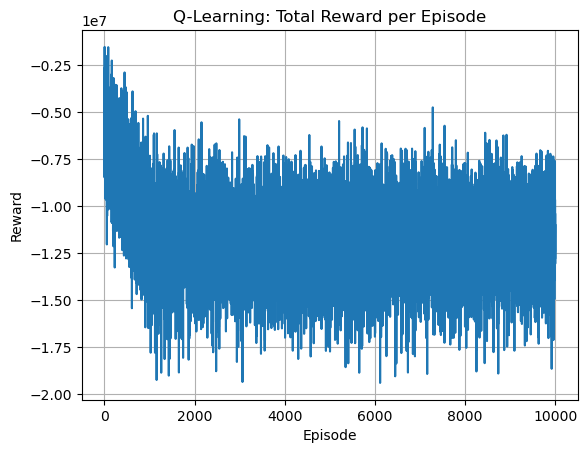

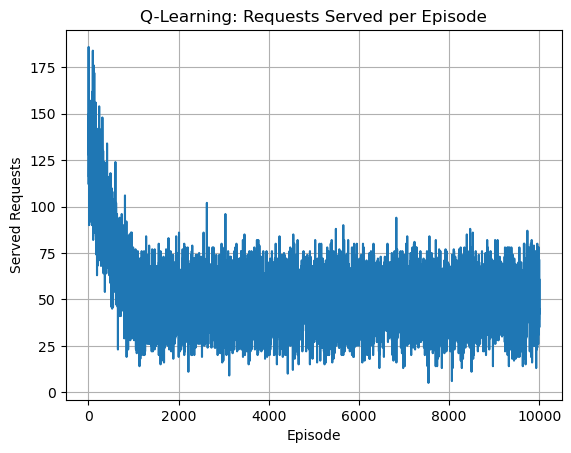

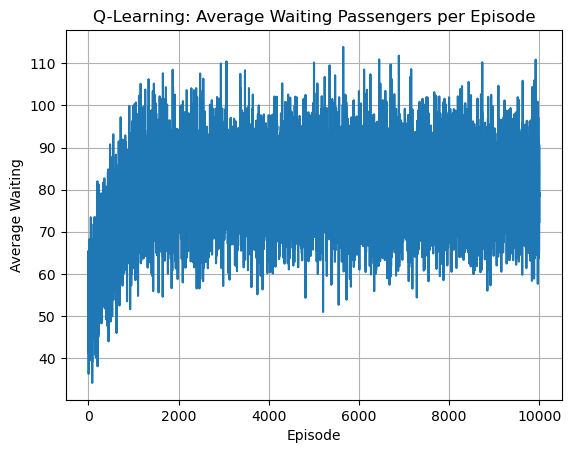


[Q-Learning] Overall Average Waiting Time across 10000 episodes: 79.25 passengers per timestep


In [3]:
import numpy as np
import random, os, pickle
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

#  ENVIRONMENT CONSTANTS
NUM_ELEVATORS = 3
NUM_FLOORS = 10
MAX_CAPACITY = 20
EPISODES = 10000
MAX_STEPS = 100
ARRIVAL_RATE = [0.2] * NUM_FLOORS

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# PASSENGER CLASS
class Passenger:
    def __init__(self, start, dest, arrival_time):
        self.start = start
        self.dest = dest
        self.arrival_time = arrival_time

# ENVIRONMENT CLASS 
class ElevatorEnvLarge:
    def __init__(self):
        self.reset()

    def reset(self):
        self.elevator_positions = [0] * NUM_ELEVATORS
        self.elevator_directions = [0] * NUM_ELEVATORS
        self.elevator_loads = [[] for _ in range(NUM_ELEVATORS)]
        self.car_calls = [[0] * NUM_FLOORS for _ in range(NUM_ELEVATORS)]  # car-call one-hots per elevator
        self.hall_requests = {floor: {'up': [], 'down': []} for floor in range(NUM_FLOORS)}
        self.time_step = 0
        return self._get_state()

    def poisson_arrivals(self):
        for floor in range(NUM_FLOORS):
            n_arrivals = np.random.poisson(ARRIVAL_RATE[floor])
            for _ in range(n_arrivals):
                dest = np.random.choice([f for f in range(NUM_FLOORS) if f != floor])
                direction = 'up' if dest > floor else 'down'
                self.hall_requests[floor][direction].append(Passenger(floor, dest, self.time_step))

    def get_priority_floor(self):
        floor_demands = [len(self.hall_requests[f]['up']) + len(self.hall_requests[f]['down']) for f in range(NUM_FLOORS)]
        return int(np.argmax(floor_demands))  # Prioritize the floor with the most demand

    def _get_state(self):
        state = []
        # Elevator positions, directions, loads
        state.extend(self.elevator_positions)
        state.extend(self.elevator_directions)
        state.extend([len(load) for load in self.elevator_loads])
        # Car calls
        for car in self.car_calls:
            state.extend(car)
        # Hall calls (binary presence)
        for floor in range(NUM_FLOORS):
            state.append(1 if len(self.hall_requests[floor]['up']) > 0 else 0)
            state.append(1 if len(self.hall_requests[floor]['down']) > 0 else 0)
        return np.array(state, dtype=np.float32)

    def step(self, actions):
        
        served = 0

        # waiting count 
        total_waiting = sum(len(self.hall_requests[f]['up']) + len(self.hall_requests[f]['down'])
                            for f in range(NUM_FLOORS))

        #  move/serve phase
        for i in range(NUM_ELEVATORS):
            pos = self.elevator_positions[i]
            action = actions[i]

            if action == 0:
                # stay idle
                self.elevator_directions[i] = 0

            elif action == 1 and pos < NUM_FLOORS - 1:
                # move up
                self.elevator_positions[i] += 1
                self.elevator_directions[i] = 1

            elif action == 2 and pos > 0:
                # move down
                self.elevator_positions[i] -= 1
                self.elevator_directions[i] = 2

            elif action == 3:
                # open/serve at current floor
                pos = self.elevator_positions[i]
                # drop off
                before = len(self.elevator_loads[i])
                self.elevator_loads[i] = [p for p in self.elevator_loads[i] if p.dest != pos]
                dropped = before - len(self.elevator_loads[i])
                if dropped > 0:
                    served += dropped
                    self.car_calls[i][pos] = 0

                # pick up (up first, then down), up to capacity
                for direction in ['up', 'down']:
                    while self.hall_requests[pos][direction] and len(self.elevator_loads[i]) < MAX_CAPACITY:
                        p = self.hall_requests[pos][direction].pop(0)
                        self.elevator_loads[i].append(p)
                        self.car_calls[i][p.dest] = 1
                        served += 1

                self.elevator_directions[i] = 0

            else:
                # invalid move or boundary; treat as idle
                self.elevator_directions[i] = 0

        # arrivals and time advance
        self.poisson_arrivals()
        self.time_step += 1

        # squared waiting-time penalty over all passengers still waiting in hall queues -----
        wait_squared = 0.0
        for f in self.hall_requests:
            for d in ['up', 'down']:
                for p in self.hall_requests[f][d]:
                    w = (self.time_step - p.arrival_time)
                    wait_squared += float(w * w)

        reward = -wait_squared  # squared penalty

        done = self.time_step >= MAX_STEPS
        return self._get_state(), reward, done, {'served': served, 'waiting': total_waiting}

#  TABULAR Q-LEARNING AGENT
def state_to_key(state: np.ndarray):
    
    #Converting the environment state vector into a hashable key.
   
    return tuple(state.astype(np.int16).tolist())

def decode_actions(action_idx, n_elevators=NUM_ELEVATORS, base=4):
    """Decode joint action index (0..4^E-1) into per-elevator actions in base-4."""
    acts = [0] * n_elevators
    tmp = action_idx
    for i in range(n_elevators - 1, -1, -1):
        acts[i] = tmp % base
        tmp //= base
    return acts

class TabularQAgent:
    def __init__(self, action_size,
                 alpha=0.1,           # learning rate
                 gamma=0.995,         # discount
                 epsilon=1.0,         # start fully exploratory
                 min_epsilon=0.1,
                 epsilon_decay=0.998  # slower decay for more exploration
                 ):
        self.Q = defaultdict(lambda: np.zeros(action_size, dtype=np.float32))
        self.action_size = action_size
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay

    def act(self, state_vec):
        key = state_to_key(state_vec)
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        # Greedy
        return int(np.argmax(self.Q[key]))

    def learn(self, s_vec, a_idx, r, s2_vec, done):
        s_key = state_to_key(s_vec)
        s2_key = state_to_key(s2_vec)
        q_sa = self.Q[s_key][a_idx]
        q_max_next = 0.0 if done else float(np.max(self.Q[s2_key]))
        target = r + self.gamma * q_max_next
        self.Q[s_key][a_idx] = q_sa + self.alpha * (target - q_sa)

    def update_epsilon(self):
        if self.epsilon > self.min_epsilon:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(dict(self.Q), f)

    def load(self, path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        self.Q = defaultdict(lambda: np.zeros(self.action_size, dtype=np.float32), data)

# TRAINING (TABULAR Q-LEARNING)
env = ElevatorEnvLarge()
STATE_SIZE = len(env._get_state())       # for reference
ACTION_SIZE = 4 ** NUM_ELEVATORS         # joint action space

agent = TabularQAgent(
    action_size=ACTION_SIZE,
    alpha=0.1,
    gamma=0.995,
    epsilon=1.0,
    min_epsilon=0.1,
    epsilon_decay=0.998
)

rewards, waiting, served = [], [], []
TARGET_SAVE = 1000  # saving Q-table every 1000 episodes

for episode in range(EPISODES):
    state = env.reset()
    ep_reward, ep_served, ep_wait = 0.0, 0, 0

    for _ in range(MAX_STEPS):
        action_idx = agent.act(state)
        actions = decode_actions(action_idx, n_elevators=NUM_ELEVATORS, base=4)

        next_state, reward, done, info = env.step(actions)
        agent.learn(state, action_idx, reward, next_state, done)

        state = next_state
        ep_reward += reward
        ep_served += info['served']
        ep_wait += info['waiting']
        if done:
            break

    agent.update_epsilon()

    rewards.append(ep_reward)
    served.append(ep_served)
    waiting.append(ep_wait / MAX_STEPS)

    if episode % TARGET_SAVE == 0:
        q_path = os.path.join(CHECKPOINT_DIR, f"q_table_ep_{episode}.pkl")
        agent.save(q_path)
        print(f"Q-table checkpoint saved at episode {episode} -> {q_path}")

    if episode % 100 == 0:
        print(f"[Q-Learn] Episode {episode}: Reward={ep_reward:.2f}, Served={ep_served}, AvgWait={ep_wait/MAX_STEPS:.2f}, Eps={agent.epsilon:.3f}")

# SAVE RESULTS
df = pd.DataFrame({
    'Episode': list(range(EPISODES)),
    'Total Reward': rewards,
    'Requests Served': served,
    'Average Waiting': waiting
})
csv_path = os.path.join(CHECKPOINT_DIR, "training_metrics_qlearn.csv")
df.to_csv(csv_path, index=False)
print(f"Metrics saved to {csv_path}")

# PLOTS
plt.figure()
plt.plot(rewards)
plt.title("Q-Learning: Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(served)
plt.title("Q-Learning: Requests Served per Episode")
plt.xlabel("Episode")
plt.ylabel("Served Requests")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(waiting)
plt.title("Q-Learning: Average Waiting Passengers per Episode")
plt.xlabel("Episode")
plt.ylabel("Average Waiting")
plt.grid(True)
plt.show()

overall_avg_waiting = np.mean(waiting)
print(f"\n[Q-Learning] Overall Average Waiting Time across {EPISODES} episodes: {overall_avg_waiting:.2f} passengers per timestep")


In [4]:
## PROXIMAL POLICY OPTIMIZATION

[PPO] Checkpoint saved at episode 0
[PPO] Episode 0: Reward=-1287866.00, Served=210, AvgWait=31.00
[PPO] Episode 100: Reward=-8316623.00, Served=50, AvgWait=65.67
[PPO] Episode 200: Reward=-10419249.00, Served=46, AvgWait=71.86
[PPO] Episode 300: Reward=-11918910.00, Served=50, AvgWait=78.77
[PPO] Episode 400: Reward=-11736663.00, Served=46, AvgWait=74.34
[PPO] Episode 500: Reward=-11390617.00, Served=42, AvgWait=73.47
[PPO] Episode 600: Reward=-13042408.00, Served=48, AvgWait=85.69
[PPO] Episode 700: Reward=-10066205.00, Served=46, AvgWait=68.77
[PPO] Episode 800: Reward=-11957453.00, Served=47, AvgWait=77.33
[PPO] Episode 900: Reward=-14001572.00, Served=52, AvgWait=85.32
[PPO] Checkpoint saved at episode 1000
[PPO] Episode 1000: Reward=-11508984.00, Served=44, AvgWait=79.08
[PPO] Episode 1100: Reward=-12157094.00, Served=47, AvgWait=79.45
[PPO] Episode 1200: Reward=-9461924.00, Served=50, AvgWait=61.13
[PPO] Episode 1300: Reward=-12454177.00, Served=42, AvgWait=74.05
[PPO] Episode 1

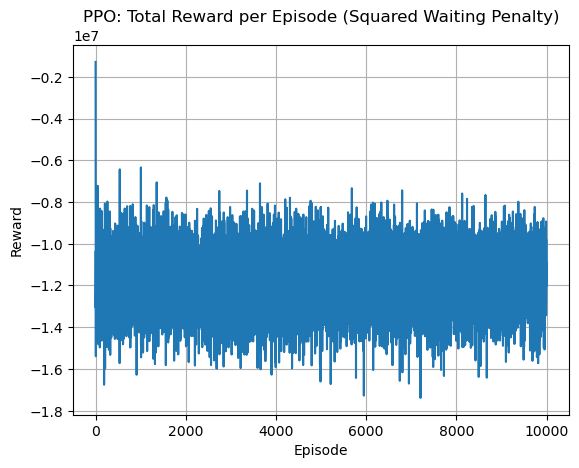

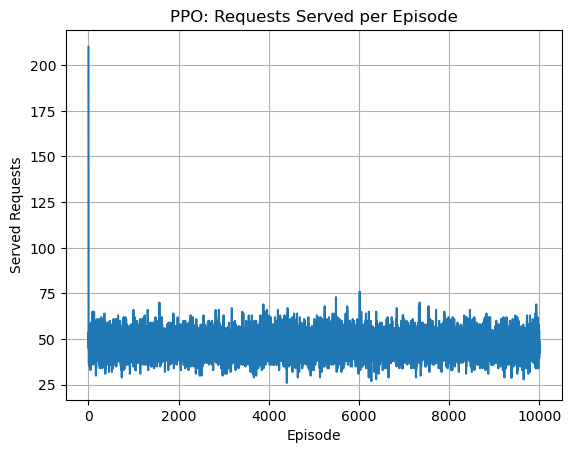

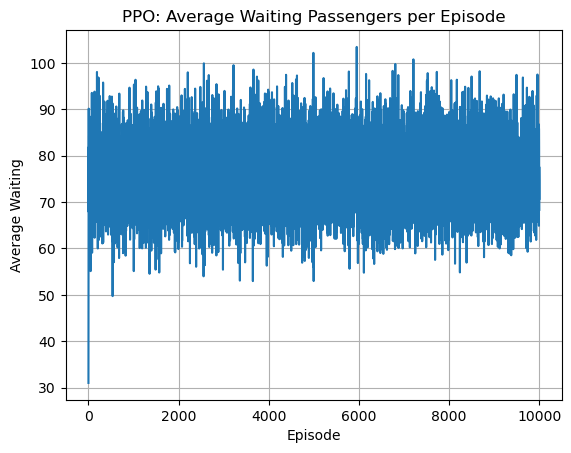


[PPO] Overall Average Waiting Time across 10000 episodes: 75.82 passengers per timestep


In [5]:
import numpy as np
import random, os
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import pandas as pd

# ENVIRONMENT CONSTANTS 
NUM_FLOORS = 10
MAX_CAPACITY = 20
EPISODES = 10000
MAX_STEPS = 100
ARRIVAL_RATE = [0.2] * NUM_FLOORS

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# PASSENGER CLASS 
class Passenger:
    def __init__(self, start, dest, arrival_time):
        self.start = start
        self.dest = dest
        self.arrival_time = arrival_time

# ENVIRONMENT CLASS
class ElevatorEnvLarge:
    def __init__(self):
        self.reset()

    def reset(self):
        self.elevator_positions = [0] * NUM_ELEVATORS
        self.elevator_directions = [0] * NUM_ELEVATORS
        self.elevator_loads = [[] for _ in range(NUM_ELEVATORS)]
        self.car_calls = [[0] * NUM_FLOORS for _ in range(NUM_ELEVATORS)]
        self.hall_requests = {floor: {'up': [], 'down': []} for floor in range(NUM_FLOORS)}
        self.time_step = 0
        # Seed initial demand so episode starts with pickups possible
        self.poisson_arrivals()
        return self._get_state()

    def poisson_arrivals(self):
        for floor in range(NUM_FLOORS):
            n_arrivals = np.random.poisson(ARRIVAL_RATE[floor])
            for _ in range(n_arrivals):
                dest = np.random.choice([f for f in range(NUM_FLOORS) if f != floor])
                direction = 'up' if dest > floor else 'down'
                self.hall_requests[floor][direction].append(Passenger(floor, dest, self.time_step))

    def get_priority_floor(self):
        floor_demands = [len(self.hall_requests[f]['up']) + len(self.hall_requests[f]['down']) for f in range(NUM_FLOORS)]
        return int(np.argmax(floor_demands))

    def _get_state(self):
        state = []
        state.extend(self.elevator_positions)
        state.extend(self.elevator_directions)
        state.extend([len(load) for load in self.elevator_loads])
        for car in self.car_calls:
            state.extend(car)
        for floor in range(NUM_FLOORS):
            state.append(1 if len(self.hall_requests[floor]['up']) > 0 else 0)
            state.append(1 if len(self.hall_requests[floor]['down']) > 0 else 0)
        return np.array(state, dtype=np.float32)

    def _serve_at_floor(self, i, pos):
        #Drop off anyone destined here; then pick up hall passengers up to capacity.
        served_here = 0
        # Drop off
        before = len(self.elevator_loads[i])
        self.elevator_loads[i] = [p for p in self.elevator_loads[i] if p.dest != pos]
        dropped = before - len(self.elevator_loads[i])
        if dropped > 0:
            served_here += dropped
            self.car_calls[i][pos] = 0
        # Pick up
        cap_left = MAX_CAPACITY - len(self.elevator_loads[i])
        k = 0
        while k < cap_left and self.hall_requests[pos]['up']:
            p = self.hall_requests[pos]['up'].pop(0)
            self.elevator_loads[i].append(p)
            self.car_calls[i][p.dest] = 1
            served_here += 1
            k += 1
        cap_left = MAX_CAPACITY - len(self.elevator_loads[i])
        k = 0
        while k < cap_left and self.hall_requests[pos]['down']:
            p = self.hall_requests[pos]['down'].pop(0)
            self.elevator_loads[i].append(p)
            self.car_calls[i][p.dest] = 1
            served_here += 1
            k += 1
        return served_here

    def step(self, actions):
        
        served = 0

        # === Arrivals at the START of the step so open can pick them up now ===
        self.poisson_arrivals()

        # Snapshot for logging
        total_waiting = sum(
            len(self.hall_requests[f]['up']) + len(self.hall_requests[f]['down'])
            for f in range(NUM_FLOORS)
        )

        # ----- move/serve phase -----
        for i in range(NUM_ELEVATORS):
            pos = self.elevator_positions[i]
            a = actions[i]

            if a == 0:
                # stay
                self.elevator_directions[i] = 0

            elif a == 1 and pos < NUM_FLOORS - 1:
                self.elevator_positions[i] += 1
                self.elevator_directions[i] = 1
                pos = self.elevator_positions[i]  # update pos after move

            elif a == 2 and pos > 0:
                self.elevator_positions[i] -= 1
                self.elevator_directions[i] = 2
                pos = self.elevator_positions[i]  # update pos after move

            elif a == 3:
                # explicit open/serve
                served += self._serve_at_floor(i, pos)
                self.elevator_directions[i] = 0
            else:
                # invalid/boundary -> idle
                self.elevator_directions[i] = 0

            
            # Always open if there are drop-offs due here OR waiting hall passengers and capacity available.   
            has_drop = any(p.dest == pos for p in self.elevator_loads[i])
            has_wait = (self.hall_requests[pos]['up'] or self.hall_requests[pos]['down'])
            cap_left = MAX_CAPACITY - len(self.elevator_loads[i])
            if has_drop or (has_wait and cap_left > 0):
                served += self._serve_at_floor(i, pos)
                self.elevator_directions[i] = 0

        # advance time
        self.time_step += 1

        # Squared waiting-time penalty
        wait_squared = 0.0
        for f in self.hall_requests:
            for d in ['up', 'down']:
                for p in self.hall_requests[f][d]:
                    w = (self.time_step - p.arrival_time)
                    wait_squared += float(w * w)

        reward = -wait_squared

        done = self.time_step >= MAX_STEPS
        return self._get_state(), reward, done, {'served': served, 'waiting': total_waiting}

# ACTION EN/DECODING 
ACTION_SIZE = 4 ** NUM_ELEVATORS

def decode_joint_action(action_idx, n_elevators=NUM_ELEVATORS, base=4):
    actions = []
    tmp = action_idx
    for _ in range(n_elevators):
        actions.append(tmp % base)
        tmp //= base
    return actions[::-1]

# PPO ACTOR-CRITIC
class ActorCritic(nn.Module):
    def __init__(self, input_dim, action_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(256, action_dim)
        self.value_head  = nn.Linear(256, 1)

    def forward(self, x):
        z = self.shared(x)
        logits = self.policy_head(z)
        value  = self.value_head(z).squeeze(-1)
        return logits, value

class PPOAgent:
    def __init__(self, state_dim, action_dim,
                 lr=0.005, gamma=0.995, gae_lambda=0.95,
                 clip_eps=0.2, value_coef=0.5, entropy_coef=0.01,
                 k_epochs=4, batch_size=64):
        self.gamma = gamma
        self.lam = gae_lambda
        self.clip_eps = clip_eps
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.k_epochs = k_epochs
        self.batch_size = batch_size

        self.net = ActorCritic(state_dim, action_dim)
        self.optimizer = optim.Adam(self.net.parameters(), lr=lr)
        self.buffer = {'s': [], 'a': [], 'r': [], 'd': [], 'logp': [], 'v': []}

    def act(self, state_np):
        s = torch.from_numpy(state_np).float().unsqueeze(0)
        logits, value = self.net(s)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        return int(action.item()), float(logp.item()), float(value.item())

    def store(self, s, a, r, d, logp, v):
        self.buffer['s'].append(s.copy())
        self.buffer['a'].append(a)
        self.buffer['r'].append(r)
        self.buffer['d'].append(d)
        self.buffer['logp'].append(logp)
        self.buffer['v'].append(v)

    def _compute_gae(self, rewards, dones, values, last_value=0.0):
        T = len(rewards)
        adv = np.zeros(T, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(T)):
            nonterminal = 1.0 - float(dones[t])
            next_value = last_value if t == T-1 else values[t+1]
            delta = rewards[t] + self.gamma * next_value * nonterminal - values[t]
            gae = delta + self.gamma * self.lam * nonterminal * gae
            adv[t] = gae
        returns = adv + np.array(values, dtype=np.float32)
        return adv, returns

    def update(self):
        s = torch.tensor(np.array(self.buffer['s']), dtype=torch.float32)
        a = torch.tensor(self.buffer['a'], dtype=torch.int64)
        r = np.array(self.buffer['r'], dtype=np.float32)
        d = np.array(self.buffer['d'], dtype=np.bool_)
        v = np.array(self.buffer['v'], dtype=np.float32)
        old_logp = torch.tensor(self.buffer['logp'], dtype=torch.float32)

        with torch.no_grad():
            _, last_v = self.net(s[-1:].clone())
            last_v = float(last_v.item())
        adv, ret = self._compute_gae(r, d, v, last_value=last_v)

        adv = torch.tensor(adv, dtype=torch.float32)
        ret = torch.tensor(ret, dtype=torch.float32)
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        N = s.size(0)
        idxs = np.arange(N)
        for _ in range(self.k_epochs):
            np.random.shuffle(idxs)
            for start in range(0, N, self.batch_size):
                mb_idx = idxs[start:start+self.batch_size]
                mb_s = s[mb_idx]
                mb_a = a[mb_idx]
                mb_old_logp = old_logp[mb_idx]
                mb_adv = adv[mb_idx]
                mb_ret = ret[mb_idx]

                logits, values = self.net(mb_s)
                dist = Categorical(logits=logits)
                new_logp = dist.log_prob(mb_a)
                entropy = dist.entropy().mean()

                ratio = (new_logp - mb_old_logp).exp()
                unclipped = ratio * mb_adv
                clipped = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                policy_loss = -torch.min(unclipped, clipped).mean()

                value_loss = F.mse_loss(values, mb_ret)
                loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), 5.0)
                self.optimizer.step()

        for k in self.buffer:
            self.buffer[k].clear()

# TRAINING
env = ElevatorEnvLarge()
STATE_SIZE = len(env._get_state())
ACTION_SIZE = 4 ** NUM_ELEVATORS

agent = PPOAgent(
    state_dim=STATE_SIZE,
    action_dim=ACTION_SIZE,
    lr=0.005,
    gamma=0.995,
    gae_lambda=0.95,
    clip_eps=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    k_epochs=4,
    batch_size=64
)

rewards, waiting, served = [], [], []
CHECKPOINT_EVERY = 1000

for episode in range(EPISODES):
    state = env.reset()
    ep_reward, ep_served, ep_wait = 0.0, 0, 0

    for t in range(MAX_STEPS):
        _ = env.get_priority_floor()

        action_idx, logp, value = agent.act(state)
        actions = decode_joint_action(action_idx)

        next_state, reward, done, info = env.step(actions)

        agent.store(state, action_idx, reward, done, logp, value)

        state = next_state
        ep_reward += reward
        ep_served += info['served']
        ep_wait += info['waiting']

        if done:
            break

    agent.update()

    rewards.append(ep_reward)
    served.append(ep_served)
    waiting.append(ep_wait / MAX_STEPS)

    if episode % CHECKPOINT_EVERY == 0:
        path = os.path.join(CHECKPOINT_DIR, f"ppo_actorcritic_ep_{episode}.pth")
        torch.save(agent.net.state_dict(), path)
        print(f"[PPO] Checkpoint saved at episode {episode}")

    if episode % 100 == 0:
        print(f"[PPO] Episode {episode}: Reward={ep_reward:.2f}, Served={ep_served}, AvgWait={ep_wait/MAX_STEPS:.2f}")

# SAVE RESULTS
df = pd.DataFrame({
    'Episode': list(range(EPISODES)),
    'Total Reward': rewards,
    'Requests Served': served,
    'Average Waiting': waiting
})
df.to_csv(os.path.join(CHECKPOINT_DIR, "training_metrics_ppo.csv"), index=False)

#
PLOTS 
plt.figure()
plt.plot(rewards)
plt.title("PPO: Total Reward per Episode (Squared Waiting Penalty)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(served)
plt.title("PPO: Requests Served per Episode")
plt.xlabel("Episode")
plt.ylabel("Served Requests")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(waiting)
plt.title("PPO: Average Waiting Passengers per Episode")
plt.xlabel("Episode")
plt.ylabel("Average Waiting")
plt.grid(True)
plt.show()

overall_avg_waiting = np.mean(waiting)
print(f"\n[PPO] Overall Average Waiting Time across {EPISODES} episodes: {overall_avg_waiting:.2f} passengers per timestep")


In [6]:
## COMPARISON

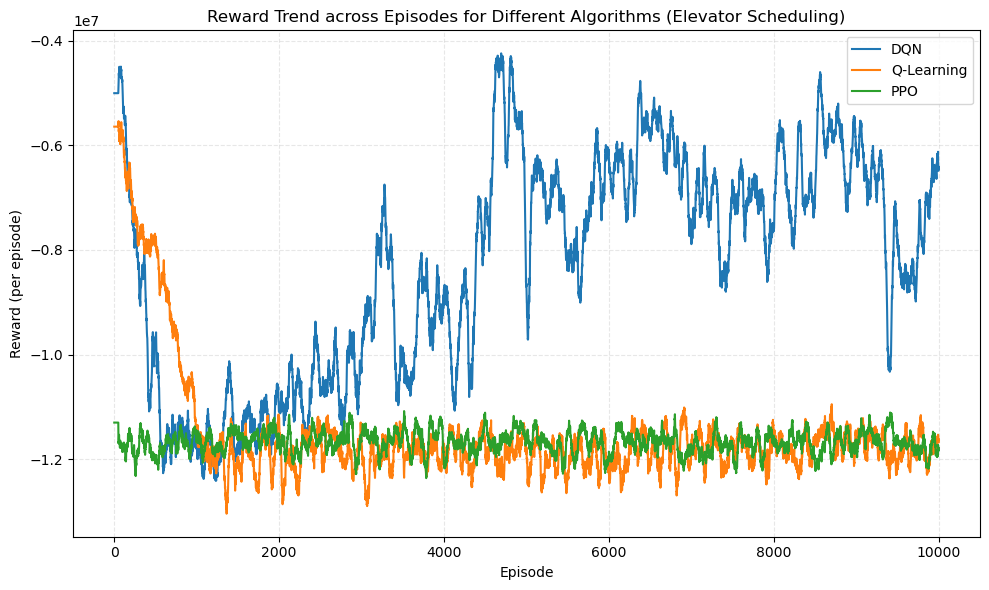

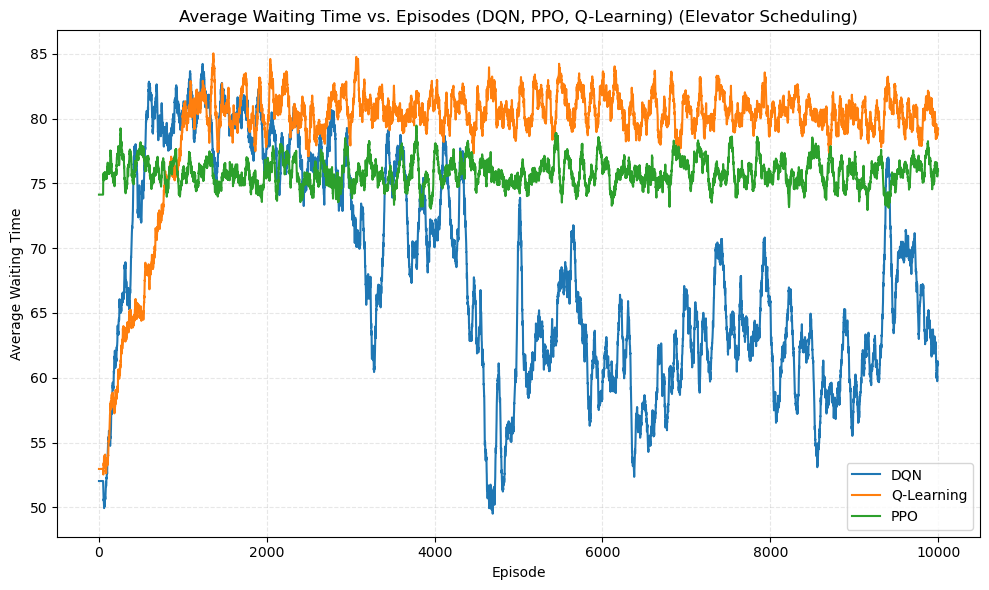

            Episodes   Mean Reward  Mean Avg Waiting
Algorithm                                           
DQN            10000 -8.256004e+06         67.794757
Q-Learning     10000 -1.150988e+07         79.250056
PPO            10000 -1.167448e+07         75.822485


In [7]:
#Comparison Plots for Q-Learning, DQN, and PPO


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = "checkpoints"  

def _rolling_mean(x, window: int):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1 or window > x.size:
        return x
    c = np.cumsum(np.insert(x, 0, 0.0))
    y = (c[window:] - c[:-window]) / float(window)
    pad = np.full(window - 1, y[0])
    return np.concatenate([pad, y])

def _load_metrics(path, algo_name):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file for {algo_name}: {path}")
    df = pd.read_csv(path)
    
    df = df.rename(columns={
        'Episode': 'Episode',
        'Total Reward': 'Total Reward',
        'Average Waiting': 'Average Waiting'
    })
    return df[['Episode', 'Total Reward', 'Average Waiting']].copy()

# -+
paths = {
    "DQN": os.path.join(CHECKPOINT_DIR, "training_metrics.csv"),
    "Q-Learning": os.path.join(CHECKPOINT_DIR, "training_metrics_qlearn.csv"),
    "PPO": os.path.join(CHECKPOINT_DIR, "training_metrics_ppo.csv"),
}

data = {}
for name, p in paths.items():
    data[name] = _load_metrics(p, name)

SMOOTHING = 50     
TITLE_SUFFIX = " (Elevator Scheduling)"
SAVE_PNG = False  

# 1) Reward Trend across Episodes for Different Algorithms 
plt.figure(figsize=(10, 6))
for name, df in data.items():
    x = df["Episode"].to_numpy()
    y = _rolling_mean(df["Total Reward"].to_numpy(), SMOOTHING)
    plt.plot(x, y, label=name)
plt.xlabel("Episode")
plt.ylabel("Reward (per episode)")
plt.title("Reward Trend across Episodes for Different Algorithms" + TITLE_SUFFIX)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(os.path.join(CHECKPOINT_DIR, "comparison_rewards.png"), dpi=150, bbox_inches="tight")
plt.show()

# 2) Average Waiting Time vs. Episodes for DQN, PPO, and Q-Learning
plt.figure(figsize=(10, 6))
for name, df in data.items():
    x = df["Episode"].to_numpy()
    y = _rolling_mean(df["Average Waiting"].to_numpy(), SMOOTHING)
    plt.plot(x, y, label=name)
plt.xlabel("Episode")
plt.ylabel("Average Waiting Time")
plt.title("Average Waiting Time vs. Episodes (DQN, PPO, Q-Learning)" + TITLE_SUFFIX)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(os.path.join(CHECKPOINT_DIR, "comparison_avg_wait.png"), dpi=150, bbox_inches="tight")
plt.show()

# Summary table
summary = []
for name, df in data.items():
    summary.append({
        "Algorithm": name,
        "Episodes": len(df),
        "Mean Reward": float(np.mean(df["Total Reward"])),
        "Mean Avg Waiting": float(np.mean(df["Average Waiting"]))
    })
print(pd.DataFrame(summary).set_index("Algorithm"))
